In [3]:
import scanpy as sc
import sys
sys.path.append('/Users/amossi/Documents/code')
import FISHspace as sp
from scipy.spatial import KDTree
import numpy as np
import squidpy as sq
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
warnings.filterwarnings('ignore')

%load_ext autoreload
%autoreload 2

# make font changeable in Illustrator
mpl.rcParams['pdf.fonttype'] = 42

# save figure with no pad
mpl.rcParams['savefig.pad_inches'] = 0
mpl.rcParams['savefig.bbox'] = 'tight'

# set axes width
mpl.rcParams['axes.linewidth'] = 0.2
mpl.rcParams['xtick.minor.pad'] = 0
mpl.rcParams['xtick.major.pad'] = 0
mpl.rcParams['ytick.minor.pad'] = 0
mpl.rcParams['ytick.major.pad'] = 0
mpl.rcParams['xtick.minor.width'] = 0.2
mpl.rcParams['xtick.major.width'] = 0.2
mpl.rcParams['ytick.minor.width'] = 0.2
mpl.rcParams['ytick.major.width'] = 0.2

# use colorblind seaborn style

/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.w

In [ ]:
eel_path = '../../data_for_visualization/GBM_Linnarsson_EEL_revision.h5ad'
adata = sc.read_h5ad(eel_path)

In [5]:
rename_dic = {
    'WR 5':'WR Endo.Ass.',
    'WR 2':'WR Periphery1',
    'WR 3':'WR Periphery2',
    'WR 1':'WR Periphery3',
    
    'WR 6':'WR HYPR1',
    'WR 8':'WR HYPR2',
    'WR 7':'WR OPC',
    'WR 4':'WR nIPC',
    
    'nIPC-RG-like':'RG-like',
    
}

adata.obs['m-states'] = pd.Categorical([rename_dic[m] if m in rename_dic else m for m in adata.obs['m-states']])

In [18]:
adata.obs['m-states'].cat.categories

Index(['AC-like 1', 'AC-like 2', 'AC-like 3', 'AC-like 4', 'AC-like 5',
       'AC-like 6', 'AC-like 7', 'Astrocyte', 'DC', 'Endothelial',
       'Erythrocyte', 'FB-like 1', 'FB-like 2', 'FB-like 3', 'GBL-like 1',
       'GBL-like 2', 'Mono 1', 'Mono 2', 'Mural cell 1', 'Mural cell 2',
       'OPC-like 1', 'OPC-like 2', 'Oligodendrocyte', 'RG-like', 'TAM-BDM 1',
       'TAM-BDM 2', 'TAM-BDM 3', 'TAM-BDM 4', 'TAM-MG', 'WR Endo.Ass.',
       'WR HYPR1', 'WR HYPR2', 'WR OPC', 'WR Periphery1', 'WR Periphery2',
       'WR Periphery3', 'WR nIPC', 'nIPC-like 1', 'nIPC-like 2', 'nIPC-like 3',
       'preOPC-like', 'unknown'],
      dtype='object')

In [36]:
palette = {
    'AC-like 1':'#2ecc71',#inchworm B4FF9F
    'AC-like 2':'#2ecc71',#inchworm B4FF9F
    'AC-like 3':'#2ecc71',#inchworm B4FF9F
    'AC-like 4':'#2ecc71',#inchworm B4FF9F
    'AC-like 5':'#2ecc71',#inchworm B4FF9F
    'AC-like 6':'#2ecc71',#inchworm B4FF9F
    'AC-like 7':'#2ecc71',#inchworm B4FF9F

    'preOPC-like':'#7befb2',#'#c2f970'

    'WR nIPC':'#e76d89',# Deep cerise
    'WR OPC':'#e76d89',# Deep cerise
    'WR Periphery1': '#D6BEDD',    
    'WR Periphery2': '#D6BEDD',
    'WR Periphery3': '#D6BEDD',
    'WR Endo.Ass.': '#D6BEDD',
    'WR HYPR2': '#C50F53',
    'WR HYPR1': '#840034',
    
    'RG-like':'#ff9470',
    'nIPC-RG-like':'#ff9470',
    
    'OPC-like 1':'#89c4f4', #bright turquoise
    'OPC-like 2':'#89c4f4', #bright turquoise
    
    'TAM-BDM 1':'#e3ba8f', #wood
    'TAM-BDM 2':'#e3ba8f',
    'TAM-BDM 3':'#e3ba8f',
    'TAM-BDM 4':'#e3ba8f', #wood

    'TAM-MG':'#a6915c',#red orange
    'Mono 1': '#c8f7c5',
    'Mono 2': '#c8f7c5',
    
    'Oligodendrocyte':'#392e4a',
    'Astrocyte':'#038aff',
    
    'Endothelial':'#C8E683', # '#d5b8ff',  
    'Mural cell 1': '#8c14fc',  #electric indigo
    'Mural cell 2': '#8c14fc',  #electric indigo

    'FB-like 2': '#9f5afd', #fff9de
    'FB-like 3': '#9f5afd', #fff9de

}

In [7]:
import matplotlib
import seaborn as sns
greens = sns.color_palette('Greens',10)
greens = matplotlib.colors.LinearSegmentedColormap.from_list("", greens[:8])

blues = sns.color_palette('Blues',10)
blues = matplotlib.colors.LinearSegmentedColormap.from_list("", blues[:8])

In [8]:
adata.raw = adata

In [9]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [10]:
genex = adata[:,'SPP1'].X.toarray()

In [11]:
genex.max()

np.float32(8.9227915)

INFO:root:First filter, 152727 cells left
INFO:root:Selecting cells in zoom area
INFO:root:Zoom filter, 4086 cells left
INFO:root:First filter, 150196 cells left
INFO:root:Selecting cells in zoom area
INFO:root:Zoom filter, 3913 cells left


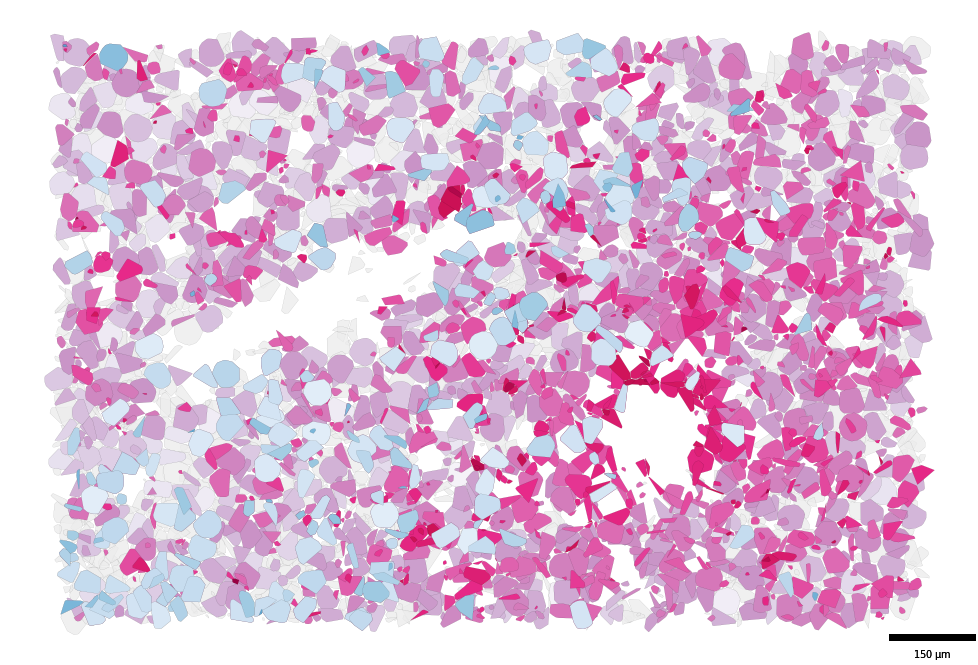

In [12]:
import matplotlib.pyplot as plt


fig,ax = plt.subplots(1,1 ,figsize=(10,10))

#xlim=(2000,5000)
#ylim=(1800,3000)

xlim=(3500,5000)
ylim=(1800,2800)
genex = adata[:,'SPP1'].X.toarray()
sp.pl.plot_polygons_expression(
    adata,
    sample='SL001B',
    genes=['SPP1'],
    cmap='PuRd',
    cluster_key='m-states',
    xlim=xlim,
    ylim=ylim,
    alpha=1,
    show_axis=False,
    area_min_size=5,
    mquant=.99999,
    bgval=1,
    vmax = genex.max(),
    vmin= genex[genex != 0].min(),
    
    ax = ax,

)

genex = adata[:,'IL1B'].X.toarray()
sp.pl.plot_polygons_expression(
    adata,
    sample='SL001B',
    genes=['IL1B'],
    cluster_key='m-states',
    cmap=blues,
    plot_grays=False,
    xlim=xlim,
    ylim=ylim,
    alpha=1,
    show_axis=False,
    mquant=.999999,
    bgval=0,
    vmax = genex.max()-.5,
    vmin= genex[genex != 0].min(),
    
    ax = ax

)

plt.savefig('figures/SL001B_IL1B_SPP1.svg',dpi=300, format='svg', transparent=True,bbox_inches='tight')
plt.show()

INFO:root:First filter, 150196 cells left
INFO:root:Selecting cells in zoom area
INFO:root:Zoom filter, 3913 cells left


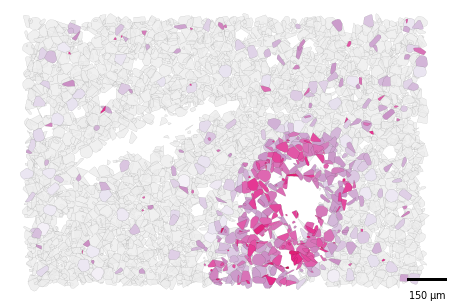

In [13]:


fig,ax = plt.subplots(1,1 ,figsize=(5,5))
xlim=(3500,5000)
ylim=(1800,2800)

genex = adata[:,'HMOX1'].X.toarray()
sp.pl.plot_polygons_expression(
    adata,
    sample='SL001B',
    genes=['HMOX1'],
    cmap='PuRd',
    cluster_key='m-states',
    xlim=xlim,
    ylim=ylim,
    alpha=1,
    show_axis=False,
    mquant=1,
    ax = ax,
    vmax = genex.max(),
    vmin= genex[genex != 0].min(),
    
)


plt.savefig('figures/HMOX1.svg',dpi=300, format='svg', transparent=True,bbox_inches='tight')


INFO:root:First filter, 3228 cells left
INFO:root:Selecting cells in zoom area
INFO:root:Zoom filter, 141 cells left


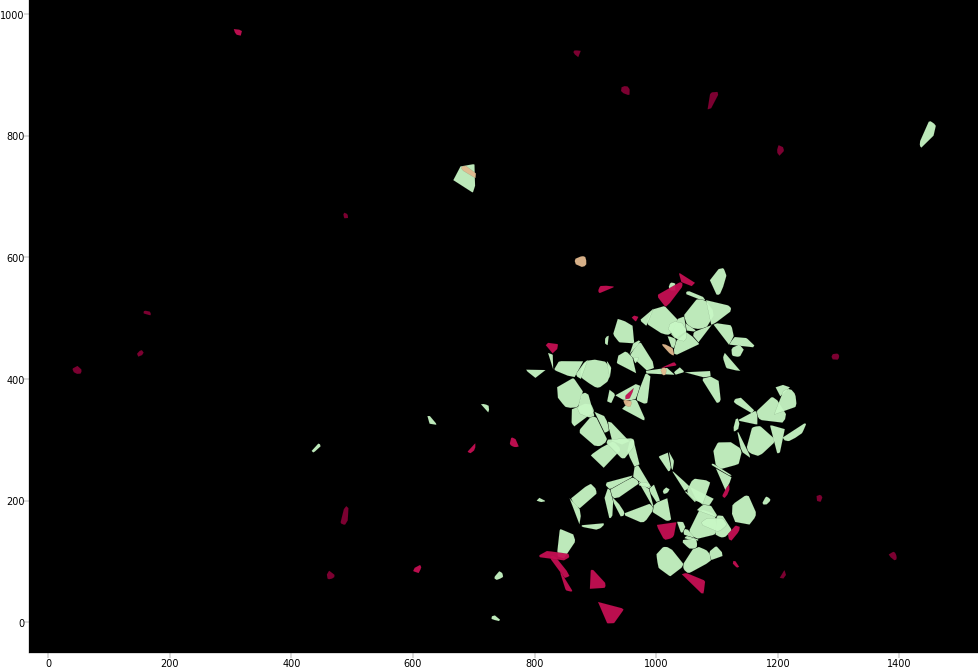

In [37]:
sp.pl.plot_polygons(
    adata,
    sample='SL001B',
    cluster_key='m-states',
    clusters = ['Mono 1','Mono 2', 'TAM-BDM 4','WR HYPR1','WR HYPR2', 'Mural cell 1', 'Mural cell 2' ],
    
    xlim=(3500,5000),
    ylim=(1800,2800),
    show_axis=True,
    palette=palette,
    figsize=(10,10),
    alpha=0.95,
    facecolor=(0,0,0),
    annotate=False,
    area_min_size=50,
    fontsize=12,
    
    save=True,
    savepath='figures/SL001B_Mono.svg',
    
)

INFO:root:First filter, 19101 cells left
INFO:root:Selecting cells in zoom area
INFO:root:Zoom filter, 6640 cells left


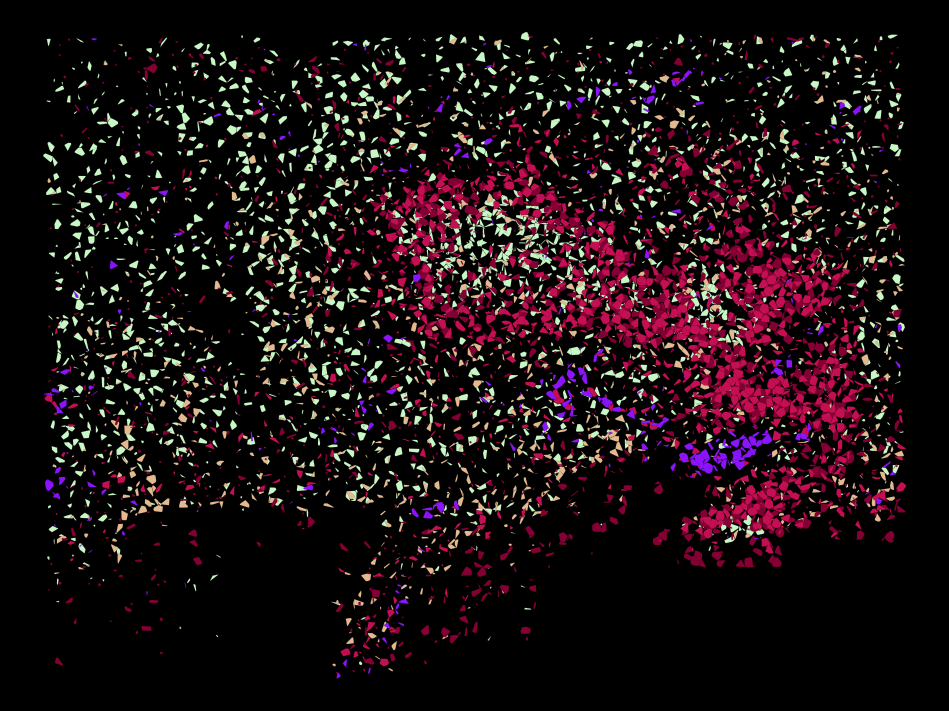

In [38]:
sp.pl.plot_polygons(
    adata,
    sample='SL046C',
    cluster_key='m-states',
    clusters = ['Mono 1','Mono 2', 'TAM-BDM 4','WR HYPR1','WR HYPR2', 'Mural cell 1' ,  'Mural cell 2'],
    xlim=(6000,10000),
    ylim=(1000,4000),

    show_axis=False,
    palette=palette,
    figsize=(10,10),
    alpha=1,
    facecolor=(0,0,0),

    area_min_size=50,
    fontsize=12,
    annotation_rotation=-90,
    annotation_text_offset=(50,-300),
    save=True,
    savepath='figures/SL046C_Mono.svg',
    
)

INFO:root:First filter, 109979 cells left
INFO:root:Selecting cells in zoom area
INFO:root:Zoom filter, 5670 cells left


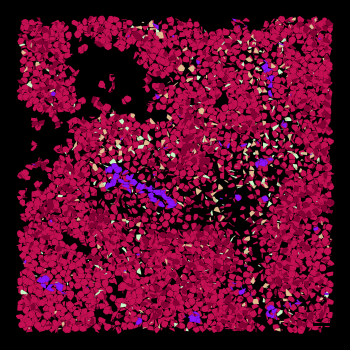

In [39]:
sp.pl.plot_polygons(
    adata,
    sample='SL035B',
    cluster_key='m-states',
    clusters = ['WR HYPR2','WR HYPR1','Mono 1','Mono 2', 'TAM-BDM 4', 'Mural cell 1', 'Mural cell 2' ],
    xlim = (11000, 13000),
    ylim= (5000, 7000),
    show_axis=False,
    palette=palette,
    figsize=(4,4),
    alpha=1,
    facecolor=(0,0,0),
    area_min_size=50,
    fontsize=12,
    save=True, 
    show_scalebar=True,
    savepath='figures/SL035B_Mono.svg',
    
)

INFO:root:First filter, 42786 cells left
INFO:root:Selecting cells in zoom area
INFO:root:Zoom filter, 2950 cells left


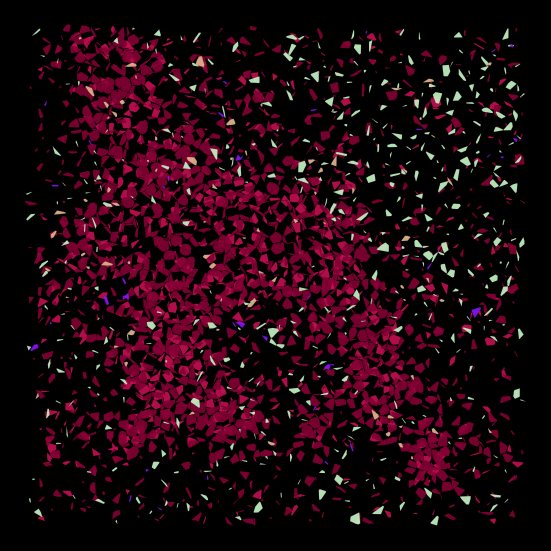

In [40]:
sp.pl.plot_polygons(
    adata,
    sample='SL061B',
    cluster_key='m-states',
    clusters = ['WR HYPR2','WR HYPR1','Mono 1','Mono 2', 'TAM-BDM 4',  'Mural cell 1', 'Mural cell 2'  ],
    xlim = (4000,6000),
    ylim = (4000,6000),
    show_axis=False,
    palette=palette,
    figsize=(6,6),
    alpha=.9,
    facecolor=(0,0,0),
    area_min_size=50,
    fontsize=12,
    save=True, 
    show_scalebar=True,
    savepath='figures/SL061B_Mono.svg',
    
)